In [1]:
import pandas as pd
import numpy as np
from NSGA2 import NSGA2_FS
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from IAMB import IAMB
from clustering import DBSCAN_Clustering

In [2]:
def generate_dataset(n_samples, n_features, n_informative, n_redundant, n_repeated, n_classes):
    X, y = make_classification(
        n_samples = n_samples,
        n_features = n_features,
        n_informative = n_informative,   
        n_redundant = n_redundant,      
        n_repeated = n_repeated,
        n_classes = n_classes,
        random_state=42,
        shuffle = False
    )

    feature_cols = [f"feature_{i+1}" for i in range(X.shape[1])]
    df = pd.DataFrame(X, columns=feature_cols)
    df["target"] = y
    return df

## <h1>Observations and Results 
<h3>(Small data - low samples + low no of features)

In [12]:
data = generate_dataset(n_samples = 1000, n_features = 50, n_informative = 2, n_redundant = 2, n_repeated = 1, n_classes = 2)
data

,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,...,feature_42,feature_43,feature_44,feature_45,feature_46,feature_47,feature_48,feature_49,feature_50,target
0,-1.050478,-1.323568,0.912474,1.009796,0.912474,-0.154925,0.700736,-0.278391,0.633361,-1.540793,...,-0.858450,1.125588,-0.272975,-0.777539,0.728685,-0.488197,1.027422,-0.663720,-0.159595,0
1,-1.580834,-2.747104,1.777419,1.850430,1.777419,0.944972,-0.226261,0.756053,-0.065548,1.981692,...,-0.417964,1.274592,0.810062,1.075176,-1.368705,1.548000,-0.761408,0.192293,-0.148223,0
2,-0.885704,-0.614600,0.501004,0.631813,0.501004,-0.878483,-1.412536,-1.743848,0.119018,-1.525319,...,1.671483,-0.107559,-0.695044,-0.041169,0.537091,0.051626,-0.205728,-0.650017,-0.662131,0
3,-1.525438,-2.967793,1.884777,1.924410,1.884777,-0.597808,0.338815,-0.994180,0.393269,1.412995,...,0.331844,-0.423776,-1.617363,-0.716640,0.157055,0.162744,0.041379,0.548708,-0.581146,0
4,-1.076826,-1.014619,0.752233,0.885267,0.752233,0.026681,0.572093,-0.084890,-1.243324,-0.961488,...,0.406477,-1.579616,1.378710,-1.244831,-0.710081,-0.597710,-1.526271,0.032576,0.213904,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,0.792945,0.687195,-0.521841,-0.625632,-0.521841,0.519147,-1.884094,1.280781,0.874839,-0.356611,...,-0.240889,0.142886,0.298590,1.090375,0.778570,0.951085,-0.352021,0.287708,1.734886,1
996,1.063154,0.887385,-0.681478,-0.823942,-0.681478,-0.096858,0.129330,0.142710,-0.103958,1.288156,...,-0.537584,0.544619,1.088981,1.980982,-1.864282,-1.027763,-0.342131,0.556130,0.764410,1
997,0.244362,0.231442,-0.171343,-0.201416,-0.171343,-1.178801,0.376374,-2.559875,0.291922,-0.026137,...,1.784793,-0.364092,-1.261689,-1.190092,1.036209,-1.686562,0.063828,-0.176226,-0.675419,1
998,1.777667,1.742310,-1.277857,-1.490927,-1.277857,-0.858359,0.696159,0.777406,1.167324,0.484341,...,-0.136359,0.314154,-0.121295,-0.205613,-0.492848,-1.889007,1.767494,0.197976,-0.081504,0


In [6]:
nsga = NSGA2_FS(classifier = 'decisiontree', population_size = 200)
nsga.fit(data)


Classifier      : decisiontree
Population size : 200
Number of fronts: 35

  Gen  10 | Pareto size:   8 | Best acc: 0.9090 | Min features: 8
  Gen  20 | Pareto size:  12 | Best acc: 0.9140 | Min features: 5
  Gen  30 | Pareto size:  12 | Best acc: 0.9140 | Min features: 2
  Gen  40 | Pareto size: 200 | Best acc: 0.9150 | Min features: 1
  Gen  50 | Pareto size: 200 | Best acc: 0.9150 | Min features: 1
  Gen  60 | Pareto size: 200 | Best acc: 0.9150 | Min features: 1
  Gen  70 | Pareto size: 200 | Best acc: 0.9150 | Min features: 1
  Gen  80 | Pareto size: 200 | Best acc: 0.9150 | Min features: 1
  Gen  90 | Pareto size: 200 | Best acc: 0.9150 | Min features: 1
  Gen 100 | Pareto size: 200 | Best acc: 0.9150 | Min features: 1

Final Pareto Front (200 solutions):
 Features_selected   Features   Accuracy
  ----------------------
 [False  True False False False False False False False False False False
 False False False False False False False False False False False False
 False False F

In [7]:
sol = nsga.find_knee_point(nsga.pareto_front_)
print(sol.mask_features, sol.obj_scores[0], sol.obj_scores[1])

[ True  True False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False] 2 0.9029999999999999


<b>NSGA 2 Alone takes a average time of 6 mins for a dataset with 50 features, 1000 samples and for 200 generations

eps calculated through elbow curve:  0.9079307887108518


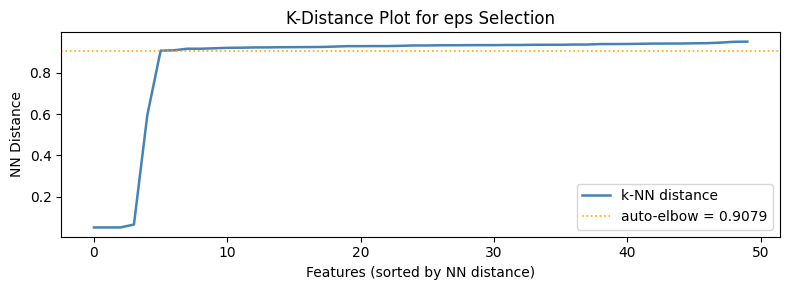

Clusters found : 4
Noise features : 38  (76.0%)
eps increased to:  0.9579307887108518
Clusters found : 1
Noise features : 0  (0.0%)
eps decreased to  0.9329307887108518
Clusters found : 1
Noise features : 10  (20.0%)
eps decreased to  0.9204307887108518
Clusters found : 6
Noise features : 27  (54.0%)

Cluster assignments:
  Cluster 0: ['feature_1', 'feature_2', 'feature_3', 'feature_4', 'feature_5', 'feature_17', 'feature_40', 'feature_41', 'feature_50']
  Cluster 1: ['feature_7', 'feature_34']
  Cluster 2: ['feature_8', 'feature_25']
  Cluster 3: ['feature_9', 'feature_13', 'feature_15', 'feature_31']
  Cluster 4: ['feature_12', 'feature_46', 'feature_48']
  Cluster 5: ['feature_32', 'feature_33', 'feature_36']
  Noise features: ['feature_6', 'feature_10', 'feature_11', 'feature_14', 'feature_16', 'feature_18', 'feature_19', 'feature_20', 'feature_21', 'feature_22', 'feature_23', 'feature_24', 'feature_26', 'feature_27', 'feature_28', 'feature_29', 'feature_30', 'feature_35', 'feature

In [11]:
feature_cols = data.columns
model = DBSCAN_Clustering()
model.build_distance_matrix(data.iloc[:,:-1].values)          
model.cluster_features(feature_names=feature_cols)

print("\nCluster assignments:")
for cid, idxs in model.clusters.items():
    names = [feature_cols[i] for i in idxs]
    print(f"  Cluster {cid}: {names}")
if model.noise:
    noise_names = [feature_cols[i] for i in model.noise]
    print(f"  Noise features: {noise_names}")

X_train, X_test, y_train, y_test = train_test_split(data.iloc[:,:-1].values, data.iloc[:,-1].values, test_size=0.2, random_state=42)

iamb = IAMB(alpha=0.01, n_bins=5)
selected = iamb.run(model.clusters, X_train,y_train)
selected_feature_names=[feature_cols[i] for i in selected]
print("\nSelected from clusters:", selected)
print("Selected feature names:", selected_feature_names)
print("length of selected features: ",len(selected_feature_names))

In [14]:
data = data[selected_feature_names+['target']]
nsga = NSGA2_FS(classifier = 'decisiontree', population_size = 200)
nsga.fit(data)


Classifier      : decisiontree
Population size : 200
Number of fronts: 46

  Gen  10 | Pareto size: 200 | Best acc: 0.9130 | Min features: 1
  Gen  20 | Pareto size: 200 | Best acc: 0.9130 | Min features: 1
  Gen  30 | Pareto size: 200 | Best acc: 0.9130 | Min features: 1
  Gen  40 | Pareto size: 200 | Best acc: 0.9130 | Min features: 1
  Gen  50 | Pareto size: 200 | Best acc: 0.9130 | Min features: 1
  Gen  60 | Pareto size: 200 | Best acc: 0.9130 | Min features: 1
  Gen  70 | Pareto size: 200 | Best acc: 0.9130 | Min features: 1
  Gen  80 | Pareto size: 200 | Best acc: 0.9130 | Min features: 1
  Gen  90 | Pareto size: 200 | Best acc: 0.9130 | Min features: 1
  Gen 100 | Pareto size: 200 | Best acc: 0.9130 | Min features: 1

Final Pareto Front (200 solutions):
 Features_selected   Features   Accuracy
  ----------------------
 [ True False False False False False False False False False False False
 False False]          1     0.8550
 [ True False False False False False False False F